In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [2]:
df = pd.read_csv("../data/processed/bank_marketing_final_clusters.csv")

# Separate features and cluster labels
X = df.drop(columns=['deposit', 'final_cluster'])
y = df['final_cluster']


In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = y


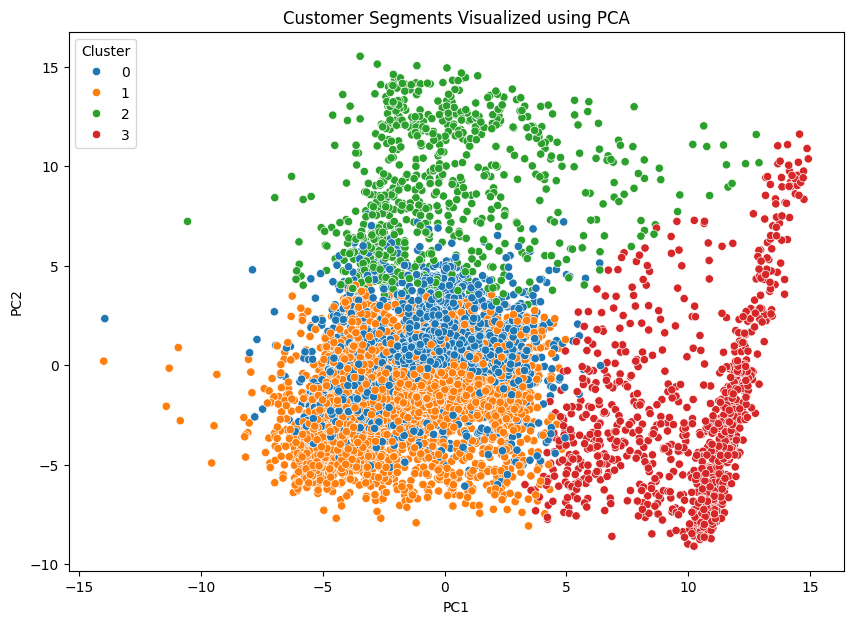

In [4]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    data=pca_df
)
plt.title("Customer Segments Visualized using PCA")
plt.show()


In [5]:
pca.explained_variance_ratio_


array([0.23819782, 0.20591363])

In [6]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
tsne_df['Cluster'] = y


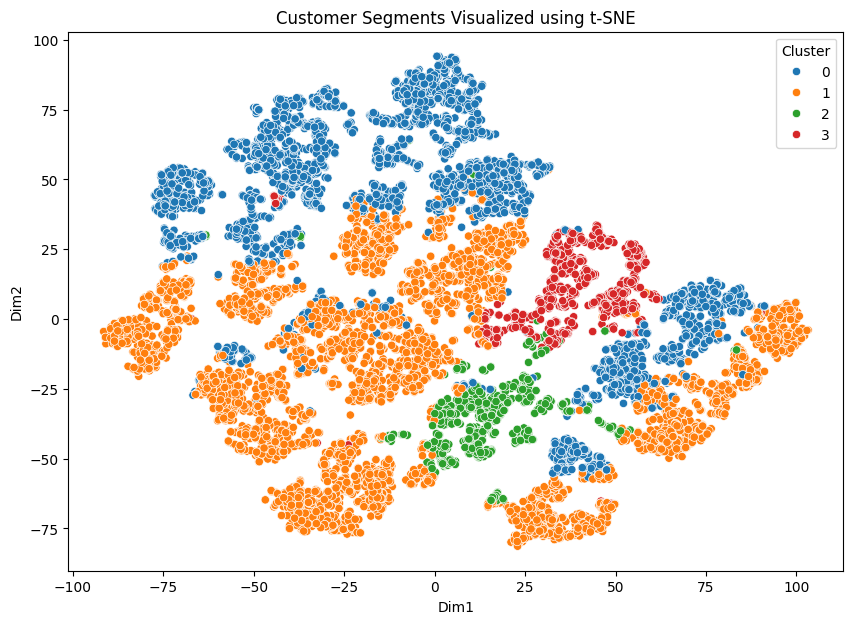

In [7]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x='Dim1',
    y='Dim2',
    hue='Cluster',
    palette='tab10',
    data=tsne_df
)
plt.title("Customer Segments Visualized using t-SNE")
plt.show()


In [8]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df)
plt.savefig("../results/pca_outputs/pca_clusters.png")
plt.close()


## Dimensionality Reduction & Visualization Insights

1. **PCA Visualization**
   - PCA successfully reduced high-dimensional customer data into two principal components.
   - Clusters show clear separation, indicating effective segmentation.

2. **t-SNE Visualization**
   - t-SNE further highlights non-linear separation among customer groups.
   - Overlapping regions suggest customers with mixed behavioral characteristics.

3. **Overall Interpretation**
   - Dimensionality reduction confirms the validity of the clustering approach.
   - Visual evidence supports the selection of optimal clusters.
